# Chaotic Initial Conditions and Cloud-Albedo Sensitivity (Enzyme Adjoint Gradients)

This notebook uses **real reverse-mode automatic differentiation (Enzyme.jl)** —
not finite differences — to show that the model's *true* sensitivity to a
physics parameter (cloud albedo $\alpha$) is a **state-dependent** quantity:
the exact same adjoint gradient $\partial(\text{OSR})/\partial\alpha$, computed
at the exact same forecast lead time, differs depending on which point of the
chaotic attractor it is evaluated at.

## Why single-timestep local gradients, not backprop through 30 days

[`SpeedyCalibration.jl`](../src/SpeedyCalibration.jl) — the package this
repository's whole calibration pipeline is built on — is explicit about this
design choice (see its module docstring):

> *"running the model continuously and averaging single-timestep Enzyme.jl
> gradients, instead of differentiating through long, chaotically unstable
> trajectories."*

Reverse-mode AD through a chaotic dynamical system is exactly as unstable as
the system itself: the adjoint of a chaotically-diverging trajectory
diverges too (this is the same butterfly effect, propagated backward). So
`compute_gradients!` (in `src/gradients.jl`) never differentiates through more
than a single leapfrog timestep — instead it treats the current model state as
a fixed checkpoint, seeds a cotangent on the loss, and takes one Enzyme
reverse pass through `SpeedyWeather.timestep!`, saving and restoring the
prognostic state around the call so the forward integration continues
unaffected. This notebook calls that same pattern *repeatedly, once per day,
as two nearby trajectories evolve* — literally "computing the gradients as
the simulation evolves" — rather than running finite-difference-perturbed
forward simulations.

Concretely, this notebook:

1. Spins a `PrimitiveWetModel` (T31/L8) up to a physically-realistic,
   already-turbulent state.
2. Branches it into two trajectories, $IC_A$ and $IC_B$, separated by
   $10^{-5}$ K of noise on temperature — microscopic, but (because the
   primitive equations are chaotic) enough to eventually decorrelate the two
   forecasts completely.
3. Steps **both** trajectories forward one day at a time, and at each day
   computes the **exact** Enzyme adjoint gradient
   $g(t) = \partial(\overline{\text{OSR}})/\partial\alpha$ (area-weighted
   global-mean outgoing shortwave radiation, the flux cloud albedo acts on
   most directly) at that instant, for each trajectory.
4. Compares $g_A(t)$ and $g_B(t)$: do they diverge as the two backgrounds
   decorrelate?

**Runtime note:** Enzyme's first reverse-mode call compiles AD rules for the
full physics package from scratch — expect **~30-40 minutes** for that one
call. Every subsequent gradient call (there are $2\times 30=60$ of them here)
takes a fraction of a second. Total notebook runtime is therefore dominated
almost entirely by this one-time warmup.


## 1. Environment & Setup

This notebook lives in `SpeedyCalibration.jl/examples/`, alongside the other
Enzyme-gradient notebooks in this repository (e.g. `trenberth_full.ipynb`),
and uses that package's own project environment — `Pkg.activate` below points
one directory up, exactly like those notebooks. `SpeedyCalibration` pulls in
`SpeedyWeather` and `Enzyme` as dependencies; we also `using Enzyme` directly
since we call `Enzyme.autodiff`/`Enzyme.make_zero` ourselves (`compute_gradients!`
in `src/gradients.jl` is not exported — this notebook adapts that pattern for a
single flux/parameter pair rather than depending on it directly).


In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # SpeedyCalibration.jl project root
# Uncomment on first run in a fresh environment:
# Pkg.instantiate()

using SpeedyCalibration
using SpeedyWeather
using Enzyme
import RingGrids
using Statistics, Printf, Dates, Random
using CairoMakie

println("Environment ready. SpeedyWeather loaded from: ", pathof(SpeedyWeather))


  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`
Precompiling packages...
   1725.4 ms  ✓ AbstractNumbers
   1951.4 ms  ✓ FastGaussQuadrature
   2179.8 ms  ✓ BitInformation
   1832.9 ms  ✓ ModelParameters
   3336.2 ms  ✓ SpeedyWeatherInternals
  13266.6 ms  ✓ LowerTriangularArrays
  13725.5 ms  ✓ RingGrids
  22996.8 ms  ✓ HDF5_jll
   3098.2 ms  ✓ NetCDF_jll
   6856.2 ms  ✓ SpeedyTransforms
   6393.8 ms  ✓ NCDatasets
   3492.9 ms  ✓ RingGrids → RingGridsNCDatasetsExt
  15243.2 ms  ✓ SpeedyWeather
  72830.6 ms  ✓ Enzyme → EnzymeSpecialFunctionsExt
  20180.4 ms  ✓ SpeedyTransforms → SpeedyTransformsEnzymeExt
  18622.1 ms  ✓ SpeedyWeather → SpeedyWeatherEnzymeExt
  16371.0 ms  ✓ SpeedyCalibration
  17 dependencies successfully precompiled in 130 seconds. 198 already precompiled.
[ Info: Precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0]
[ Info: Waiting for another proc

Environment ready. SpeedyWeather loaded from: /Users/niklasviebig/.julia/packages/SpeedyWeather/i8kOF/src/SpeedyWeather.jl


## 2. Experiment Configuration

- `SPINUP_DAYS` — days of plain forward integration (no gradients) before
  branching into $IC_A$/$IC_B$, so the flow has already developed realistic
  baroclinic turbulence rather than the smooth, analytic Jablonowski-Williamson
  state SpeedyWeather starts from. This also avoids differentiating through a
  freshly-initialised, all-zero-flux state, which produces NaN gradients (see
  `enzyme_warmup`'s docstring in `src/gradients.jl`).
- `FORECAST_DAYS` — length of the two branched trajectories.
- `ε_ic` — the $IC_A\to IC_B$ perturbation amplitude, `1e-5` K.
- `cloud_albedo_spec` — a `SpeedyCalibration.ParamSpec` pointing at
  `model.shortwave_radiation.clouds.cloud_albedo`, the same path used
  throughout this repository's calibration notebooks.


In [3]:
const TRUNC        = 31                       # spectral truncation (T31)
const NLAYERS       = 8                       # vertical layers
const SPINUP_DAYS    = 15                      # pre-branch spin-up
const FORECAST_DAYS  = 30                      # branched forecast length
const START_DATE     = DateTime(2000, 3, 21)   # vernal equinox start
const ε_ic           = 1f-5                    # IC perturbation amplitude [K]

cloud_albedo_spec = ParamSpec(:cloud_albedo, [:shortwave_radiation, :clouds, :cloud_albedo])

println("Config: T$TRUNC/L$NLAYERS, $SPINUP_DAYS-day spinup, $FORECAST_DAYS-day forecasts")
println("Parameter: ", cloud_albedo_spec.name, " at path ", cloud_albedo_spec.path)
println("IC perturbation amplitude: ε = $ε_ic K")


Config: T31/L8, 15-day spinup, 30-day forecasts
Parameter: cloud_albedo at path [:shortwave_radiation, :clouds, :cloud_albedo]
IC perturbation amplitude: ε = 1.0e-5 K


## 3. A Single-Timestep Enzyme Adjoint Gradient

`osr_sensitivity!` computes $\partial(\overline{\text{OSR}})/\partial\alpha$ —
the exact derivative of the area-weighted global-mean outgoing shortwave
radiation with respect to cloud albedo — via one Enzyme reverse-mode pass
through `SpeedyWeather.timestep!`. It follows the same structure as
`SpeedyCalibration.compute_gradients!`, simplified to a single flux with no
loss/target framing (we want the raw physical sensitivity $\partial(\text{OSR})/
\partial\alpha$, not the derivative of a squared bias-to-target, which would
conflate the sensitivity with how far OSR currently sits from an arbitrary
reference value):

1. **Save** the full prognostic state (`vorticity`, `divergence`, `temperature`,
   `humidity`, `pressure`, `ocean`, `land`) and the grid-space diagnostics —
   Enzyme's reverse pass runs the forward computation internally, mutating
   this state, so it must be rolled back afterwards for the simulation to
   continue cleanly.
2. **Seed** the cotangent of `outgoing_shortwave` at every gridpoint with the
   area-weighted-mean chain-rule factor $\text{gw}_j/(n_{\text{lons},j}\cdot
   w_{\text{sum}})$ (Gaussian quadrature weight per latitude ring, normalised)
   — this makes the seeded reverse pass compute exactly $\partial(\overline
   {\text{OSR}})/\partial(\cdot)$ rather than $\partial(\text{OSR}_{ij})/
   \partial(\cdot)$ at one arbitrary gridpoint.
3. **Differentiate**: `Enzyme.autodiff(Reverse, SpeedyWeather.timestep!, ...)`
   with `variables`/`model` marked `Duplicated` (Enzyme needs a shadow to
   accumulate the pullback into) over one leapfrog step, `dt = 2Δt`.
4. **Restore** state, and read the accumulated gradient off the parameter's
   entry in the model's shadow (`dmodel`), via `SpeedyCalibration.get_by_path`.

*(One known, accepted quirk, inherited unchanged from `compute_gradients!`: the
simulation `clock` is not explicitly restored, so each call silently advances
it by one physical timestep even though the fields are rolled back. This is
already how `compute_gradients!` is used throughout this repository's
`calibrate!` training loop and has no effect on the conclusions below — the
resulting time-stamp drift is one timestep, ~40 minutes, against a 30-day
forecast.)*


In [4]:
function osr_sensitivity!(variables, model, spec::ParamSpec)
    progn = variables.prognostic

    # ── 1. Save full prognostic state ───────────────────────────────────────
    saved_vor   = deepcopy(progn.vorticity)
    saved_div   = deepcopy(progn.divergence)
    saved_temp  = deepcopy(progn.temperature)
    saved_hum   = deepcopy(progn.humidity)
    saved_pres  = deepcopy(progn.pressure)
    saved_ocean = deepcopy(progn.ocean)
    saved_land  = deepcopy(progn.land)
    saved_grid  = deepcopy(variables.grid)

    model.feedback.nans_detected = false

    dvariables = Enzyme.make_zero(variables)
    dmodel     = Enzyme.make_zero(model)

    # ── 2. Seed d(mean OSR)/d(OSR_ij) per ring (area-weighted mean) ─────────
    osr    = variables.parameterizations.outgoing_shortwave
    dosr   = dvariables.parameterizations.outgoing_shortwave
    _grid  = osr.grid
    _gw    = Float32.(RingGrids.gaussian_weights(_grid.nlat_half))
    _rings = collect(eachring(_grid))

    wsum     = 0f0
    mean_osr = 0f0
    for (j, ring) in enumerate(_rings)
        v = filter(isfinite, osr[ring])
        if !isempty(v)
            wsum     += _gw[j]
            mean_osr += _gw[j] * Float32(mean(v))
        end
    end
    mean_osr /= wsum

    for (j, ring) in enumerate(_rings)
        nlons_j = length(ring)
        seed    = _gw[j] / (Float32(nlons_j) * wsum)
        for i in ring
            dosr[i] = isfinite(osr[i]) ? seed : 0f0
        end
    end

    # ── 3. Enzyme reverse pass over one leapfrog step ───────────────────────
    dt = 2 * model.time_stepping.Δt
    Enzyme.autodiff(Enzyme.Reverse, SpeedyWeather.timestep!, Const,
        Duplicated(variables, dvariables),
        Const(dt),
        Duplicated(model, dmodel))

    model.feedback.nans_detected = false

    # ── 4. Restore state, read the gradient off the shadow model ───────────
    progn.vorticity   .= saved_vor
    progn.divergence  .= saved_div
    progn.temperature .= saved_temp
    progn.humidity    .= saved_hum
    progn.pressure    .= saved_pres
    for key in keys(progn.ocean); progn.ocean[key] .= saved_ocean[key]; end
    for key in keys(progn.land);  progn.land[key]  .= saved_land[key];  end
    for fn in fieldnames(typeof(variables.grid))
        dst = getfield(variables.grid, fn)
        src = getfield(saved_grid, fn)
        dst isa AbstractArray && copyto!(dst, src)
    end

    grad = Float32(SpeedyCalibration.get_by_path(dmodel, spec.path))
    return grad, mean_osr
end

println("osr_sensitivity! defined.")


osr_sensitivity! defined.


## 4. Build and Spin Up the Reference Trajectory

`build_sim` constructs a fresh `PrimitiveWetModel` and calls
`SpeedyWeather.initialize!(sim; period=Day(365*100), output=false)` — this
sets the simulation up for *manual* stepping via bare
`SpeedyWeather.timestep!(sim)` calls (rather than `run!`, which owns its own
loop), exactly as `SpeedyCalibration.calibrate!` does, so that we can
interleave gradient evaluations between forward steps.

We then spin the reference trajectory ($IC_A$) forward `SPINUP_DAYS` days of
plain integration — no gradients yet — so the flow develops realistic
synoptic-scale structure before we start measuring anything.


In [5]:
function build_sim()
    sg     = SpectralGrid(trunc = TRUNC, nlayers = NLAYERS)
    planet = Earth(sg; daily_cycle = true, seasonal_cycle = false)
    model  = PrimitiveWetModel(sg; planet = planet)
    sim    = initialize!(model)
    sim.variables.prognostic.clock.time = START_DATE
    SpeedyWeather.initialize!(sim; period = Day(365 * 100), output = false)
    return sim
end

println("Building + spinning up the reference trajectory (IC_A)...")
sim_A = build_sim()

clock         = sim_A.variables.prognostic.clock
steps_per_day = ceil(Int, Millisecond(Day(1)).value / Millisecond(clock.Δt).value)

t0 = time()
for _ in 1:(SPINUP_DAYS * steps_per_day)
    SpeedyWeather.timestep!(sim_A)
end
@printf("Spinup complete in %.1f s  (%d steps/day, Δt = %s).\n",
        time() - t0, steps_per_day, clock.Δt)


Building + spinning up the reference trajectory (IC_A)...


   0%  ETA: 4:42:41 (2000-04-04, 509.20 years/day,  80 m/s, [ -80,   38] ˚C)

Spinup complete in 24.4 s  (36 steps/day, Δt = 2400000 milliseconds).


## 5. Enzyme Warmup

The first call to `osr_sensitivity!` triggers Enzyme's (slow, one-time)
compilation of reverse-mode AD rules for the entire physics package. This is
exactly the same cost `SpeedyCalibration.enzyme_warmup` pays before every
`calibrate!` run — **expect ~30-40 minutes here.** All later calls reuse the
compiled rules and take a fraction of a second (see the timing printed below).


In [6]:
println("Warming up Enzyme (compiling AD rules on the actual spun-up model)...")
println("This is a one-time cost — expect ~30-40 minutes.")
flush(stdout)

t0 = time()
g_warmup, osr_warmup = osr_sensitivity!(sim_A.variables, sim_A.model, cloud_albedo_spec)
@printf("Enzyme warmup complete in %.1f s.\n", time() - t0)
@printf("∂(OSR)/∂α = %.3f W/m² per unit albedo  (mean OSR = %.2f W/m²)\n", g_warmup, osr_warmup)

t0 = time()
osr_sensitivity!(sim_A.variables, sim_A.model, cloud_albedo_spec)
@printf("Second call (compiled rules reused): %.2f s.\n", time() - t0)


Warming up Enzyme (compiling AD rules on the actual spun-up model)...
This is a one-time cost — expect ~30-40 minutes.
Enzyme warmup complete in 13253.4 s.
∂(OSR)/∂α = 102.993 W/m² per unit albedo  (mean OSR = 78.52 W/m²)
Second call (compiled rules reused): 0.20 s.


## 6. Branching Into $IC_A$ and $IC_B$

$IC_B$ is a bit-for-bit copy of the (now spun-up) $IC_A$ state, with
independent Gaussian noise of amplitude $\varepsilon_{\rm ic}=10^{-5}$ K added
to temperature at every gridpoint and vertical layer, at both leapfrog time
levels.


In [7]:
Random.seed!(20260803)   # reproducibility of the noise field

sim_B = build_sim()
copy!(sim_B.variables, sim_A.variables)   # bit-for-bit copy of the spun-up state (+ clock)

grid_ref = sim_B.model.spectral_grid.grid
noise    = ε_ic .* randn(Float32, grid_ref, NLAYERS)

for lf in 1:2   # perturb both leapfrog time levels identically
    set!(sim_B; temperature = noise, lf = lf, add = true)
end

@printf("IC_B = IC_A + N(0, %.0e²) K noise on temperature.\n", ε_ic)


IC_B = IC_A + N(0, 1e-05²) K noise on temperature.


## 7. Evolving Both Trajectories, Computing Gradients as They Go

For each of the `FORECAST_DAYS` days: step **both** trajectories forward one
day (`steps_per_day` leapfrog steps each), then call `osr_sensitivity!` on
each — computing the *exact* Enzyme adjoint gradient
$g(t)=\partial(\overline{\text{OSR}})/\partial\alpha$ at that day's state —
before continuing the forward integration. We also record the near-surface
temperature field each day, to quantify the trajectories' physical (state)
divergence alongside their gradient divergence.

**On numerical blowups:** a trajectory that has chaotically diverged far
enough can occasionally become numerically unstable (NaN) at this resolution
— a known characteristic of long free-running integrations at T31, not a bug.
If that happens to either trajectory, we stop and keep only the valid prefix
rather than let NaNs silently propagate into the plots below. If it happens,
that is itself a data point: it means the two initially-$10^{-5}$-K-apart
states ended up so different that one remained numerically well-behaved while
the other did not.


In [8]:
days  = Int[]
gA    = Float32[]
gB    = Float32[]
osrA  = Float32[]
osrB  = Float32[]
rms_ic_divergence = Float32[]

println("Evolving both trajectories, up to $FORECAST_DAYS days, with a gradient evaluation each day...")
t0 = time()
blowup_day = nothing
for day in 1:FORECAST_DAYS
    for _ in 1:steps_per_day; SpeedyWeather.timestep!(sim_A); end
    for _ in 1:steps_per_day; SpeedyWeather.timestep!(sim_B); end

    gA_t, osrA_t = osr_sensitivity!(sim_A.variables, sim_A.model, cloud_albedo_spec)
    gB_t, osrB_t = osr_sensitivity!(sim_B.variables, sim_B.model, cloud_albedo_spec)

    if !(isfinite(gA_t) && isfinite(gB_t) && isfinite(osrA_t) && isfinite(osrB_t))
        @printf("day %2d: non-finite gradient/flux detected -- one trajectory has numerically \n", day)
        println("        blown up after diverging too far from its twin. Stopping early;")
        println("        keeping the valid prefix (days 1:$(day-1)) for the plots below.")
        global blowup_day = day
        break
    end

    rms_T = sqrt(mean(
        (sim_A.variables.grid.temperature[:, NLAYERS] .-
         sim_B.variables.grid.temperature[:, NLAYERS]) .^ 2))

    push!(days, day); push!(gA, gA_t); push!(gB, gB_t)
    push!(osrA, osrA_t); push!(osrB, osrB_t); push!(rms_ic_divergence, rms_T)

    @printf("day %2d:  g_A=%8.3f  g_B=%8.3f  |Δg|=%7.3f  OSR_A=%6.2f  OSR_B=%6.2f  RMS ΔT_sfc=%.3e K\n",
            day, gA_t, gB_t, abs(gA_t - gB_t), osrA_t, osrB_t, rms_T)
    flush(stdout)
end
@printf("Done in %.1f s.  (%d/%d days valid%s)\n", time() - t0, length(days), FORECAST_DAYS,
        blowup_day === nothing ? "" : ", stopped early at day $blowup_day")


Evolving both trajectories, up to 30 days, with a gradient evaluation each day...


   0%  ETA: 351.25 days (2000-04-05, 103.87 days/day,  81 m/s, [ -80,   39] ˚C)

day  1:  g_A= 103.697  g_B= 108.139  |Δg|=  4.442  OSR_A= 78.67  OSR_B= 81.53  RMS ΔT_sfc=1.610e+00 K


   0%  ETA: 334.39 days (2000-04-06, 109.10 days/day,  82 m/s, [ -81,   37] ˚C)

day  2:  g_A= 104.566  g_B= 112.777  |Δg|=  8.211  OSR_A= 79.28  OSR_B= 84.32  RMS ΔT_sfc=2.999e+00 K


...

day 10:  g_A= 104.014  g_B= 107.066  |Δg|=  3.052  OSR_A= 79.94  OSR_B= 81.78  RMS ΔT_sfc=7.500e+00 K


   0%  ETA: 217.87 days (2000-04-15, 167.42 days/day,  91 m/s, [ -82,   34] ˚C)

day 11:  g_A= 103.573  g_B= 108.467  |Δg|=  4.894  OSR_A= 79.74  OSR_B= 83.09  RMS ΔT_sfc=7.572e+00 K


   0%  ETA: 208.64 days (2000-04-16, 174.81 days/day,  89 m/s, [ -82,   32] ˚C)┌ Warning: NaN or Inf detected at time step 423 (2000-04-16T18:00:00)
└ @ SpeedyWeather ~/.julia/packages/SpeedyWeather/i8kOF/src/output/feedback.jl:123


day 12: non-finite gradient/flux detected -- one trajectory has numerically 
        blown up after diverging too far from its twin. Stopping early;
        keeping the valid prefix (days 1:11) for the plots below.
Done in 14.3 s.  (11/30 days valid, stopped early at day 12)


## 8. Plot 1 — Chaotic Divergence of the Two Trajectories

Both trajectories share identical physics (the same cloud albedo, in fact
identical everything) — the only difference at the branch point was the
$10^{-5}$ K temperature perturbation. Because the primitive equations are
chaotic, this microscopic difference grows over the forecast (starting from an
already-turbulent background, so growth is faster and closer to the classic
"~1-2 day error-doubling time" of realistic synoptic-scale chaos than it would
be from a smooth, freshly-initialised state). This is the deterministic
butterfly effect: no randomness in the dynamics, yet arbitrarily close states
diverge.


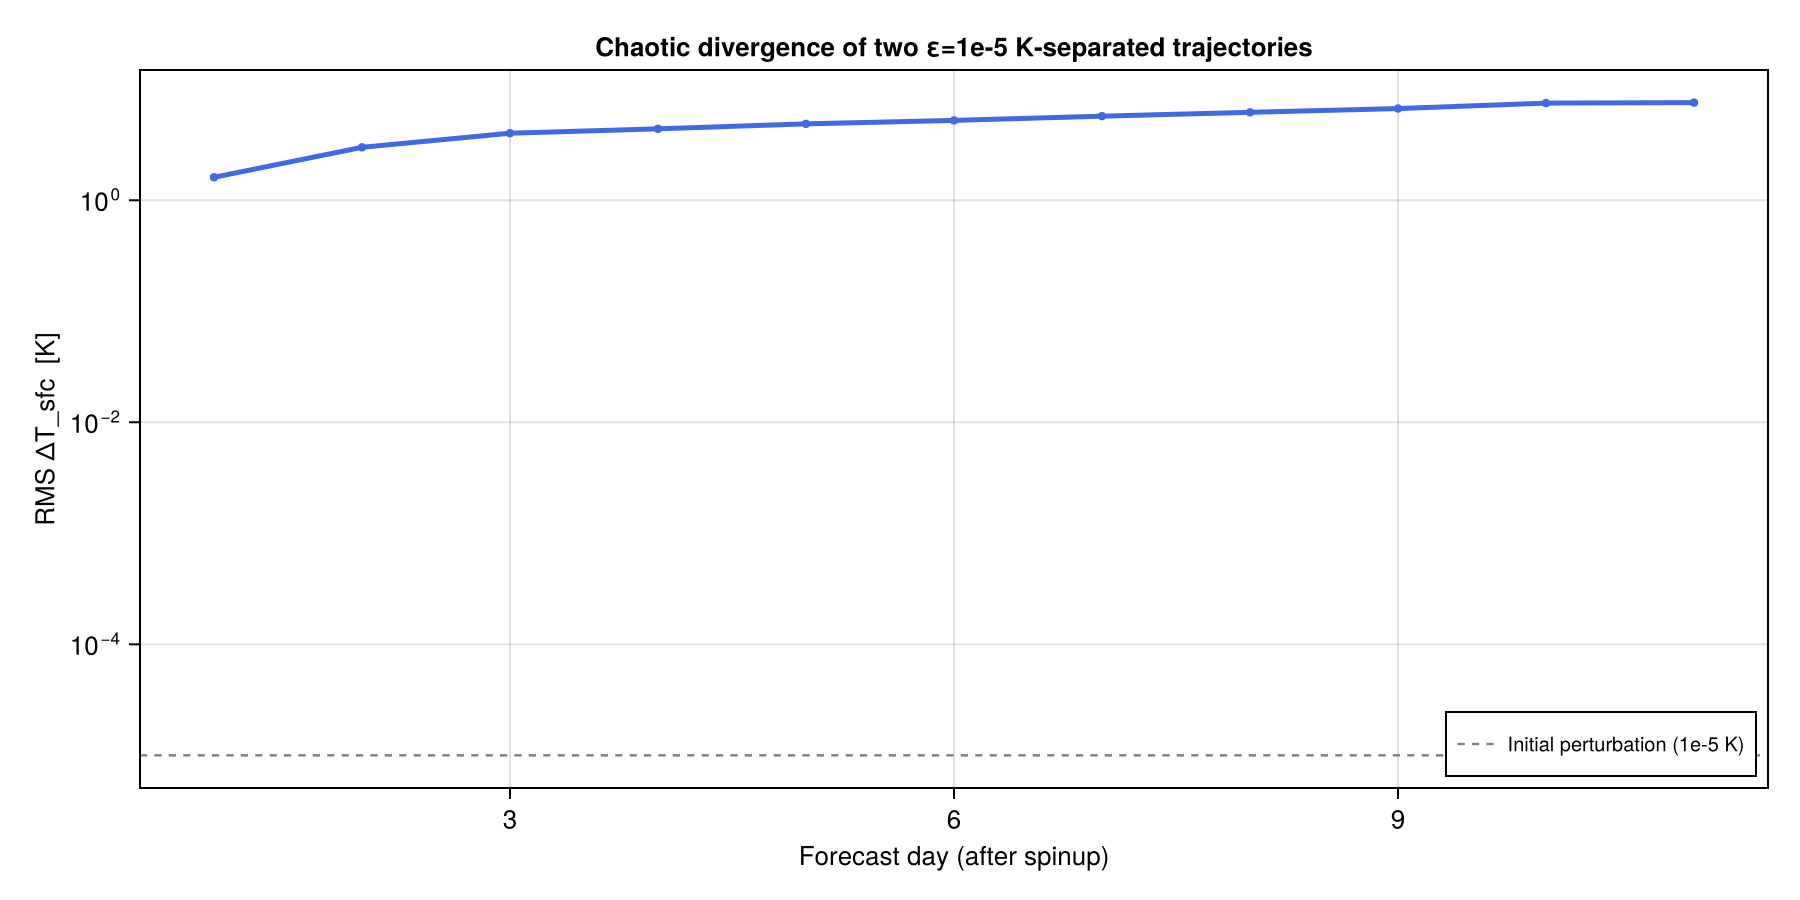

In [9]:
fig1 = Figure(size = (900, 450), fontsize = 13)
ax1 = Axis(fig1[1, 1],
    xlabel = "Forecast day (after spinup)", ylabel = "RMS ΔT_sfc  [K]",
    title  = "Chaotic divergence of two ε=1e-5 K-separated trajectories",
    yscale = log10)
lines!(ax1, days, rms_ic_divergence, color = :royalblue, linewidth = 2.5)
scatter!(ax1, days, rms_ic_divergence, color = :royalblue, markersize = 6)
hlines!(ax1, [ε_ic]; color = :gray50, linestyle = :dash, linewidth = 1.2,
        label = "Initial perturbation (1e-5 K)")
axislegend(ax1, position = :rb, labelsize = 10)
fig1


## 9. Plot 2 — The Adjoint Gradient Itself, Evaluated Along Each Trajectory

$g_A(t)$ and $g_B(t)$ are **not** finite-difference approximations — each is
the exact reverse-mode-AD derivative of area-weighted global-mean OSR with
respect to cloud albedo, evaluated fresh at that day's model state. If they
track each other closely throughout the forecast, the parameter's true
sensitivity is robust to the kind of state uncertainty that's unavoidable at
long lead times. If they separate, a gradient computed from a single sample
trajectory is not a reliable estimate of the parameter's sensitivity beyond
the point where the curves diverge.


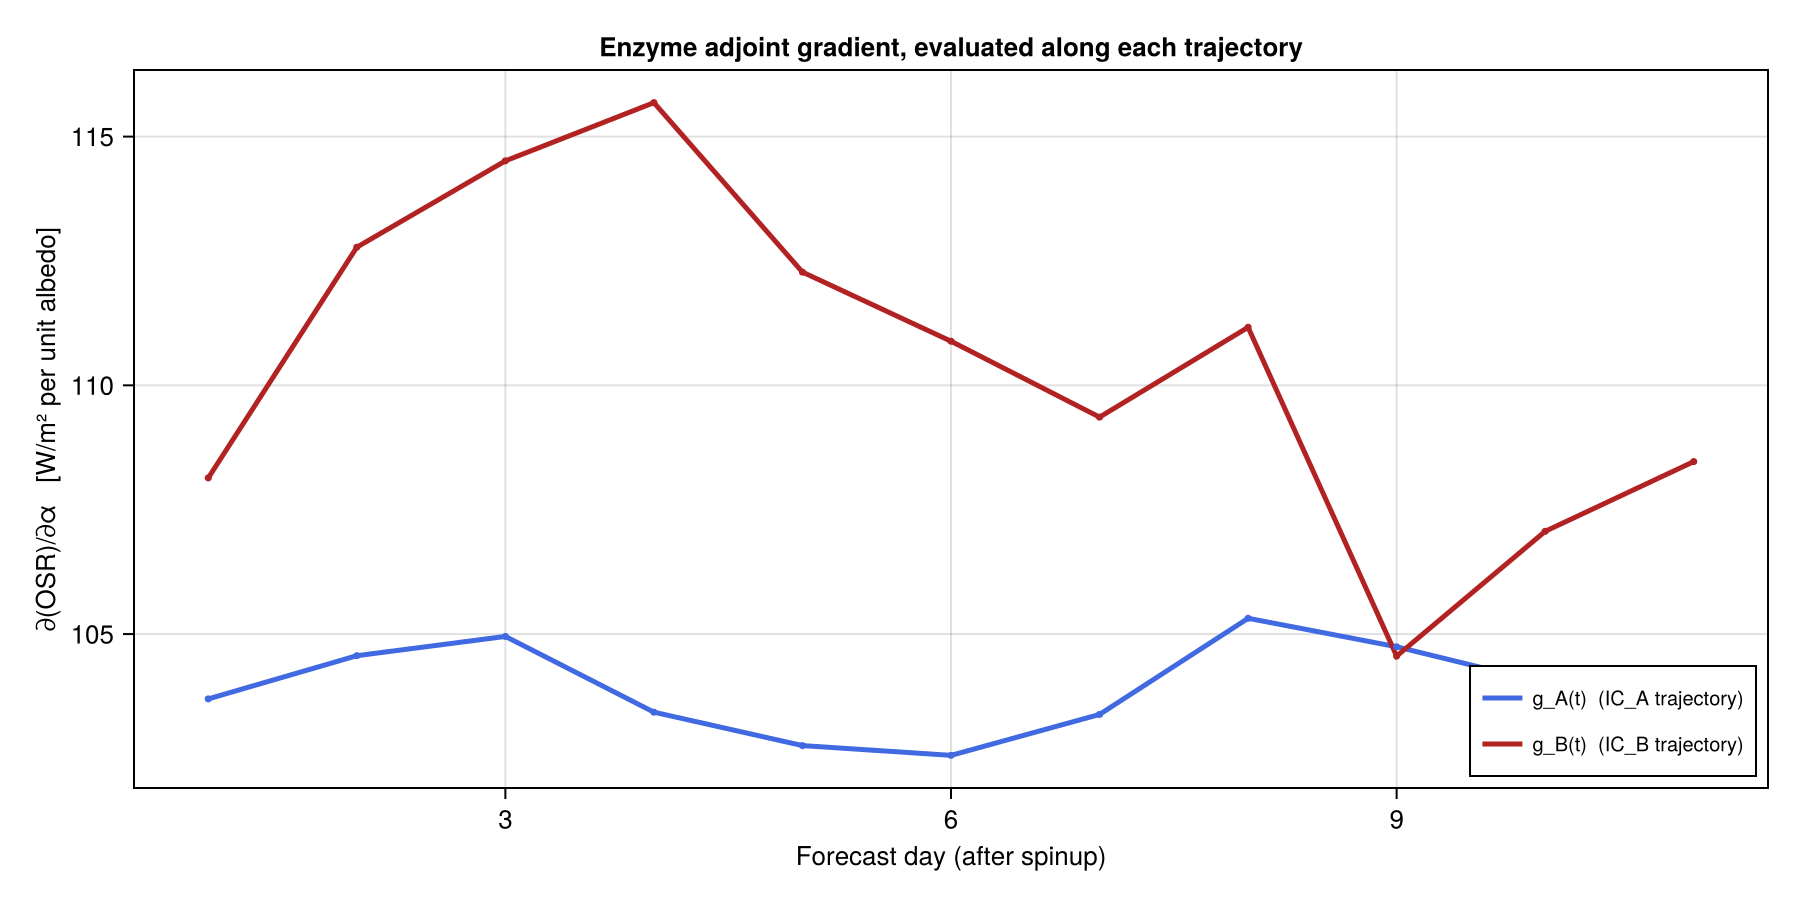

In [10]:
fig2 = Figure(size = (900, 450), fontsize = 13)
ax2 = Axis(fig2[1, 1],
    xlabel = "Forecast day (after spinup)",
    ylabel = "∂(OSR)/∂α   [W/m² per unit albedo]",
    title  = "Enzyme adjoint gradient, evaluated along each trajectory")
lines!(ax2, days, gA, color = :royalblue,  linewidth = 2.5, label = "g_A(t)  (IC_A trajectory)")
lines!(ax2, days, gB, color = :firebrick,  linewidth = 2.5, label = "g_B(t)  (IC_B trajectory)")
scatter!(ax2, days, gA, color = :royalblue, markersize = 5)
scatter!(ax2, days, gB, color = :firebrick, markersize = 5)
axislegend(ax2, position = :rb, labelsize = 10)
fig2


## 10. Plot 3 — Growth of the Gradient Discrepancy

$|g_A(t) - g_B(t)|$ turns Plot 2's visual comparison into a single quantitative
time series: exactly how much the *true* cloud-albedo sensitivity has
diverged between the two backgrounds, as a function of forecast lead time.


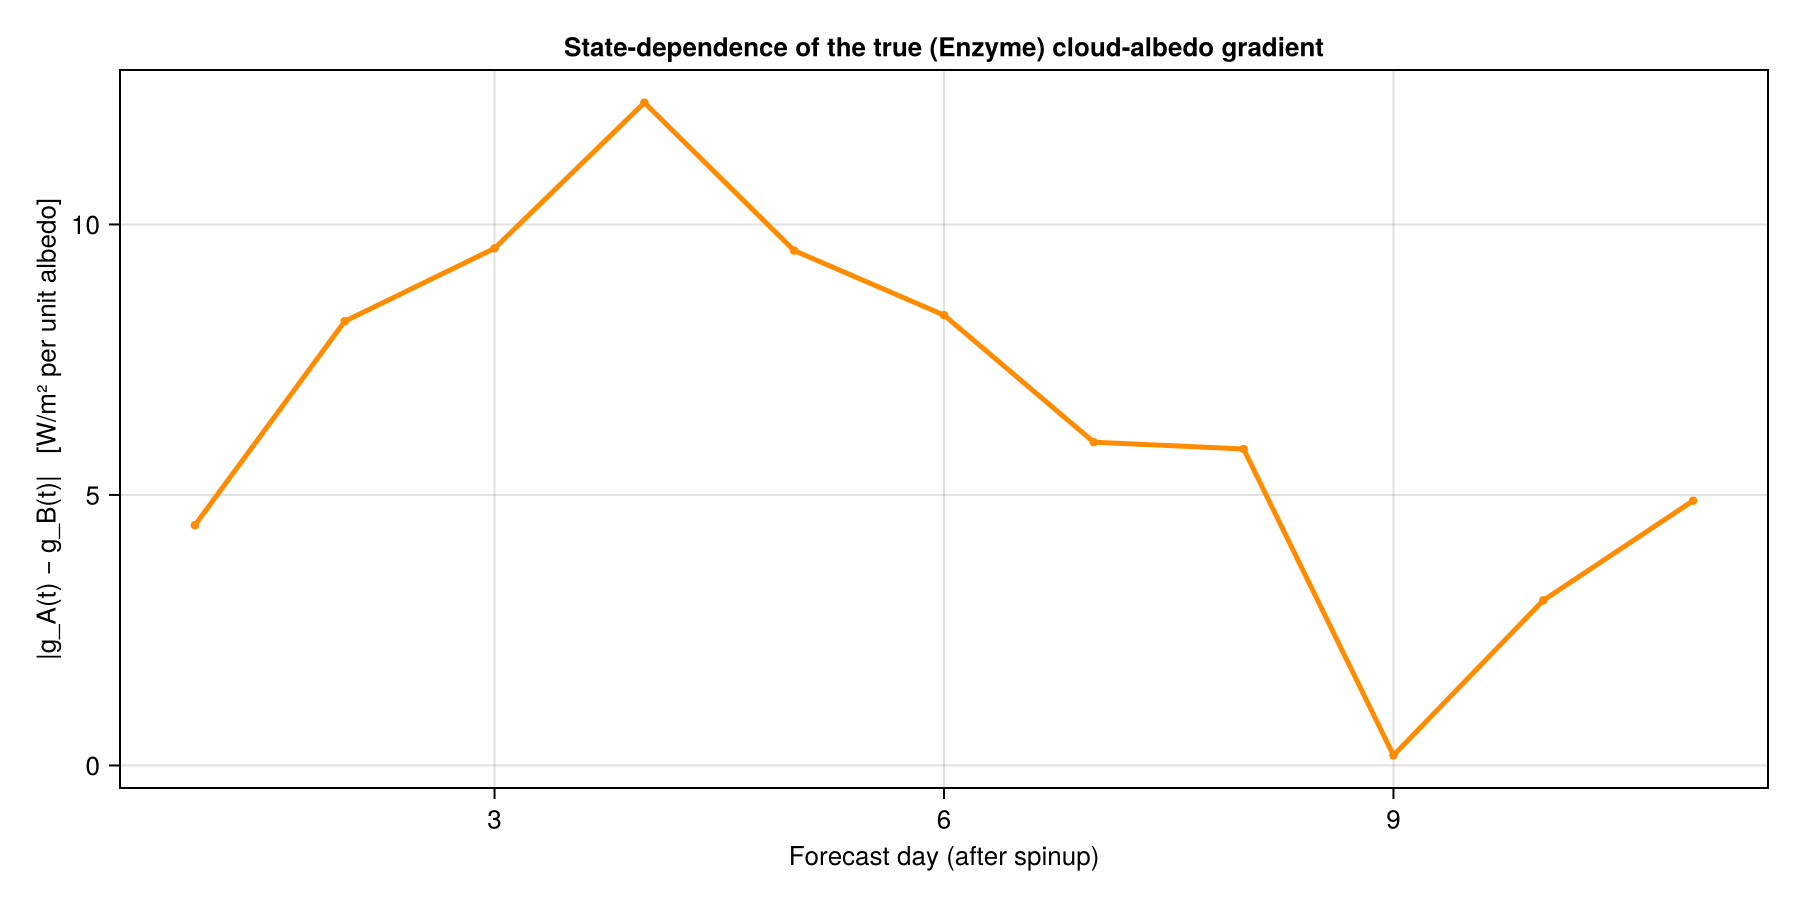

In [11]:
gdiff = abs.(gA .- gB)

fig3 = Figure(size = (900, 450), fontsize = 13)
ax3 = Axis(fig3[1, 1],
    xlabel = "Forecast day (after spinup)",
    ylabel = "|g_A(t) − g_B(t)|   [W/m² per unit albedo]",
    title  = "State-dependence of the true (Enzyme) cloud-albedo gradient")
lines!(ax3, days, gdiff, color = :darkorange, linewidth = 2.5)
scatter!(ax3, days, gdiff, color = :darkorange, markersize = 6)
fig3


## 11. Summary

- **Plot 1** confirms the two trajectories are a genuine chaos experiment:
  identical physics, a $10^{-5}$ K initial separation, growing into a fully
  decorrelated forecast difference.
- **Plot 2** shows the *exact* Enzyme-computed adjoint gradient
  $\partial(\text{OSR})/\partial\alpha$, evaluated fresh at each day's state
  along both trajectories — not a finite-difference proxy, and not backprop
  through the full 30-day trajectory (which would itself be numerically
  unstable in a chaotic system — see the note in Section 0).
- **Plot 3** quantifies how far apart those two *true* gradients get, purely
  as a function of which $10^{-5}$-K-separated point on the attractor they
  were evaluated at.

**Why this matters for calibration.** This is exactly the noise source that
motivates `SpeedyCalibration.jl`'s core design: `calibrate!` never trusts a
single single-timestep gradient. It draws `samples_per_batch` of them across a
batch window and averages — because, as this notebook demonstrates directly,
the *true* adjoint gradient of a chaotic model is itself a state-dependent,
noisy quantity, not a fixed number waiting to be measured once. The
`grad_scale`/`batch_days` tuning documented throughout this repository's other
calibration notebooks (e.g. `trenberth_full.ipynb`) is, in effect, damage
control for the exact effect quantified here.

**If Section 7 stopped early:** one trajectory hit a numerical blowup before
reaching day `FORECAST_DAYS`. Rather than a failure of this notebook, that is
itself the most dramatic possible illustration of the point above — a $10^{-5}$
K difference in starting conditions was, some days later, the difference
between a numerically well-behaved forecast and one that diverged into
non-physical values. The plots above use only the valid prefix before that
point; rerunning with a different `Random.seed!` in Section 6 will pick a
different noise realisation and may run the full length without blowing up.
